In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns if needed
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("/Users/akashkumarsamantray/Desktop/amz_uk_price_prediction_dataset.csv")
df

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


In [ ]:
## Part 1: Analyzing Best-Seller Trends Across Product Categories

In [ ]:
## Crosstab Analysis

In [3]:
category_bestseller_ct = pd.crosstab(
    df['category'],
    df['isBestSeller']
)

category_bestseller_ct.head()

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


In [ ]:
## Calculate the Proportion of Best Sellers

In [4]:
bestseller_proportion = pd.crosstab(
    df['category'],
    df['isBestSeller'],
    normalize='index'
) * 100

bestseller_proportion.head()

isBestSeller,False,True
category,,
3D Printers,99.596774,0.403226
3D Printing & Scanning,99.950824,0.049176
Abrasive & Finishing Products,98.000000,2.000000
Action Cameras,99.941072,0.058928
Adapters,98.818898,1.181102


In [ ]:
## Sort Categories by Best-Seller Percentage

In [5]:
bestseller_sorted = (
    bestseller_proportion[True]
    .sort_values(ascending=False)
)

bestseller_sorted.head(20)

category
Grocery                           5.813467
Smart Home Security & Lighting    5.769231
Health & Personal Care            5.768628
Mobile Phone Accessories          4.247104
Power & Hand Tools                3.533895
Billiard, Snooker & Pool          3.212851
Pet Supplies                      3.020028
Home Brewing & Wine Making        2.845528
Wind Instruments                  2.800000
Mirrors                           2.800000
Professional Medical Supplies     2.734375
PC & Video Games                  2.546634
Bakeware                          2.510460
Material Handling Products        2.500000
Bedding Accessories               2.439024
Tableware                         2.409639
Arts & Crafts                     2.408629
Baby                              2.265781
Lighting                          2.255639
Window Treatments                 2.092050
Name: True, dtype: float64

In [ ]:
## Display Top Categories

In [6]:
top_bestseller_categories = bestseller_sorted.head(10)

print(top_bestseller_categories)

category
Grocery                           5.813467
Smart Home Security & Lighting    5.769231
Health & Personal Care            5.768628
Mobile Phone Accessories          4.247104
Power & Hand Tools                3.533895
Billiard, Snooker & Pool          3.212851
Pet Supplies                      3.020028
Home Brewing & Wine Making        2.845528
Wind Instruments                  2.800000
Mirrors                           2.800000
Name: True, dtype: float64


In [ ]:
## Visualization

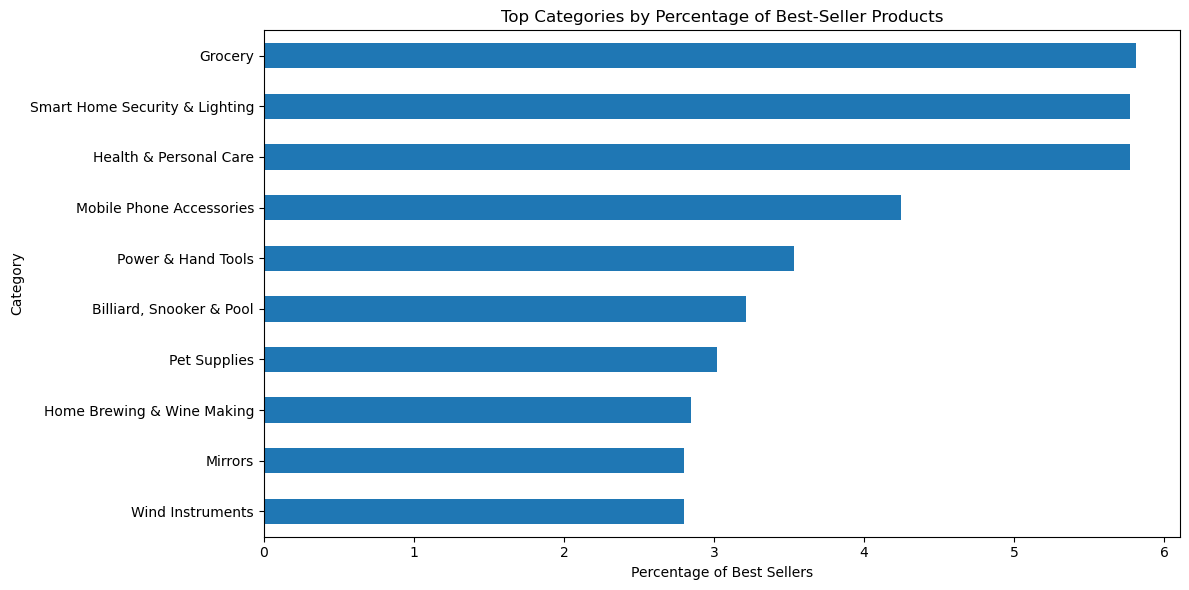

In [7]:
plt.figure(figsize=(12,6))

top_bestseller_categories.sort_values().plot(
    kind='barh'
)

plt.title('Top Categories by Percentage of Best-Seller Products')
plt.xlabel('Percentage of Best Sellers')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

In [ ]:
## Statistical Tests:

In [ ]:
## Create the Contingency Table

In [8]:
contingency_table = pd.crosstab(
    df['category'],
    df['isBestSeller']
)

contingency_table.head()

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


In [ ]:
## Perform the Chi-Square Test

In [9]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 36540.20270061387
P-value: 0.0
Degrees of Freedom: 295


In [ ]:
## Interpret the Chi-Square Test

In [10]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Reject the null hypothesis


In [ ]:
## Calculate Cramér's V

In [11]:
import numpy as np

n = contingency_table.sum().sum()

min_dim = min(
    contingency_table.shape[0] - 1,
    contingency_table.shape[1] - 1
)

cramers_v = np.sqrt(
    chi2 / (n * min_dim)
)

print("Cramer's V:", cramers_v)

Cramer's V: 0.1222829439760564


In [ ]:
## Visualizations:

In [12]:
category_bestseller_top.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Best-Seller Status by Product Category')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45, ha='right')
plt.legend(title='isBestSeller')

plt.tight_layout()
plt.show()

NameError: name 'category_bestseller_top' is not defined